# Database Inquiry
Loading and exploring `ranfill_data.db`

In [1]:
import sqlite3
import pandas as pd
import os
import matplotlib.pyplot as plt

# 1. Define the database file path
db_path = '../data/ranfill_data.db'


In [2]:
# 2. File size
file_size_bytes = os.path.getsize(db_path)
print(f"File size: {file_size_bytes / (1024 * 1024):.2f} MB")

File size: 8.67 MB


In [3]:
# Connect and load the data
conn = sqlite3.connect(db_path)
query = "SELECT * FROM rainfall_data"
df = pd.read_sql_query(query, conn)
conn.close()

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

In [4]:
# 3. Number of rows
print(f"Number of rows: {len(df)}")
# 4. Number of columns
print(f"Number of columns: {len(df.columns)}")

Number of rows: 132585
Number of columns: 4


In [8]:
# 5. Columns names
# 5. Columns names
for col in df.columns.tolist():
    print(f"Column names: {col}")

Column names: location
Column names: date
Column names: rainfall_nearest_mm
Column names: rainfall_bilinear_mm


In [6]:
# 6. First only 5 rows (latest 5 rows based on date)
latest_5_rows = df.sort_values(by='date', ascending=False).head(5)
latest_5_rows

,location,date,rainfall_nearest_mm,rainfall_bilinear_mm
132584,Bangalore,2025-12-31,0.0,0.0
132583,Pooparai,2025-12-31,0.0,0.0
132582,Kottakudi,2025-12-31,0.0,0.0
132581,Bangalore,2025-12-30,0.0,0.0
132580,Pooparai,2025-12-30,0.0,0.0


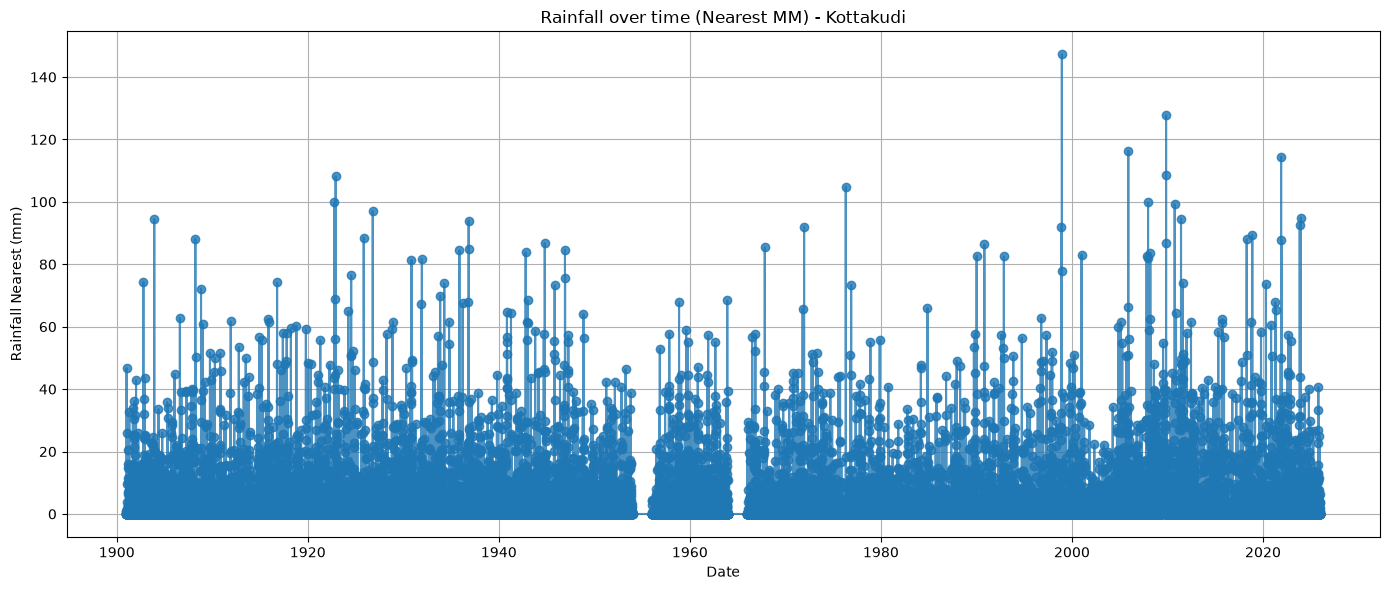

In [7]:
# 7. Plot Date Vs One of column as graph (using rainfall_nearest_mm)
plt.figure(figsize=(14, 6))

# We will plot the data for the first location found to make the line chart clean
if not df.empty:
    location = df['location'].iloc[0]
    df_loc = df[df['location'] == location].sort_values('date')
    plt.plot(df_loc['date'], df_loc['rainfall_nearest_mm'], marker='o', linestyle='-', alpha=0.8)
    plt.title(f'Rainfall over time (Nearest MM) - {location}')
    plt.xlabel('Date')
    plt.ylabel('Rainfall Nearest (mm)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot.")